# GANs

In [1]:
# ============================================================
# CELL 1: Install packages
# ============================================================

# torchmetrics is used later for computing the FID score.
# torch-fidelity provides the Inception network used by TorchMetrics.

!pip install -q torchmetrics[image] torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.7 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 2: Import required libraries
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [3]:
# ============================================================
# CELL 3: Device configuration and random seed
# ============================================================

# Use GPU if available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Fixing random seeds makes results more reproducible.
torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Using device: cuda


In [4]:
# ============================================================
# CELL 4: Download and prepare MNIST
# ============================================================

# Generator outputs will use Tanh().
#
# Tanh produces values in the range:
#
#       [-1, 1]
#
# Therefore we also convert the real MNIST images to [-1, 1].
#
# Original ToTensor() range:
#
#       [0, 1]
#
# Normalize(mean=0.5, std=0.5):
#
#       x_new = (x - 0.5) / 0.5
#
# converts:
#
#       0 -> -1
#       1 -> +1

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Number of training images:", len(train_dataset))
print("Number of batches:", len(train_loader))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.33MB/s]

Number of training images: 60000
Number of batches: 469


Image batch shape: torch.Size([128, 1, 28, 28])
Label batch shape: torch.Size([128])


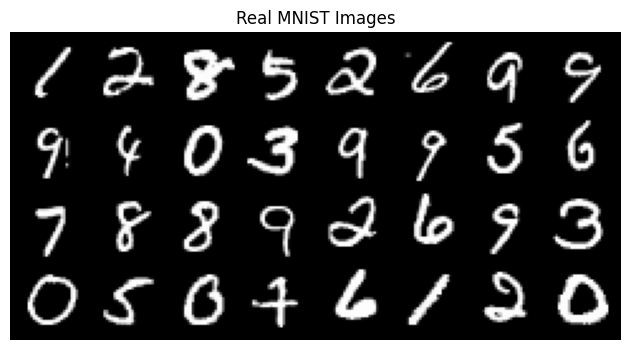

In [5]:
# ============================================================
# CELL 5: Visualize some real MNIST images
# ============================================================

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Convert [-1,1] -> [0,1] only for visualization.
images_display = (images + 1) / 2

grid = make_grid(
    images_display[:32],
    nrow=8
)

plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Real MNIST Images")
plt.show()

In [6]:
# ============================================================
# CELL 6: Vanilla GAN hyperparameters
# ============================================================

# Dimension of the random latent vector.
LATENT_DIM = 100

# MNIST images are 28 x 28.
IMAGE_SIZE = 28 * 28

LEARNING_RATE = 0.0002

# 10 is sufficient for a classroom demonstration.
# Increase this to 30-50 for better images.
NUM_EPOCHS = 25

In [7]:
# ============================================================
# CELL 7: Vanilla GAN Generator
# ============================================================

class VanillaGenerator(nn.Module):

    def __init__(self, latent_dim=100):
        super().__init__()

        # Input:
        #       random noise z
        #       shape = [batch_size, latent_dim]
        #
        # Output:
        #       flattened MNIST image
        #       shape = [batch_size, 784]

        self.model = nn.Sequential(

            # 100 -> 256
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),

            # 256 -> 512
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            # 512 -> 1024
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            # 1024 -> 784
            nn.Linear(1024, 28 * 28),

            # Output pixels in [-1, 1]
            nn.Tanh()
        )

    def forward(self, z):

        # Pass random noise through the neural network.
        img = self.model(z)

        return img

In [8]:
# ============================================================
# CELL 8: Vanilla GAN Discriminator
# ============================================================

class VanillaDiscriminator(nn.Module):

    def __init__(self):
        super().__init__()

        # Input:
        #       flattened MNIST image
        #       28 x 28 = 784
        #
        # Output:
        #       ONE logit
        #
        # Positive logit -> probably real
        # Negative logit -> probably fake

        self.model = nn.Sequential(

            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1)

            # IMPORTANT:
            # We DO NOT place Sigmoid here.
            #
            # BCEWithLogitsLoss automatically applies the
            # sigmoid operation internally.
        )

    def forward(self, img):

        return self.model(img)

In [9]:
# ============================================================
# CELL 9: Create Vanilla GAN
# ============================================================

vanilla_G = VanillaGenerator(
    latent_dim=LATENT_DIM
).to(device)

vanilla_D = VanillaDiscriminator().to(device)

print(vanilla_G)
print()

print(vanilla_D)

VanillaGenerator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

VanillaDiscriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


In [10]:
# ============================================================
# CELL 10: Loss function and optimizers
# ============================================================

# Binary classification:
#
# Real -> 1
# Fake -> 0

criterion = nn.BCEWithLogitsLoss()


# Generator optimizer
optimizer_G = optim.Adam(
    vanilla_G.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)


# Discriminator optimizer
optimizer_D = optim.Adam(
    vanilla_D.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

In [11]:
# ============================================================
# CELL 11: Train Vanilla GAN
# ============================================================

vanilla_G.train()
vanilla_D.train()

for epoch in range(NUM_EPOCHS):

    running_d_loss = 0
    running_g_loss = 0

    for real_images, _ in train_loader:

        # ----------------------------------------------------
        # Prepare real images
        # ----------------------------------------------------

        batch_size = real_images.size(0)

        # Move images to GPU/CPU.
        real_images = real_images.to(device)

        # Vanilla GAN uses fully-connected layers.
        # Therefore flatten:
        #
        # [B, 1, 28, 28]
        #
        # becomes
        #
        # [B, 784]

        real_images = real_images.view(batch_size, -1)


        # ====================================================
        # STEP 1: TRAIN THE DISCRIMINATOR
        # ====================================================

        optimizer_D.zero_grad()


        # ----------------------------------------------------
        # Discriminator on REAL images
        # ----------------------------------------------------

        real_output = vanilla_D(real_images)

        # Real images should have target = 1.
        real_targets = torch.ones(
            batch_size,
            1,
            device=device
        )

        loss_real = criterion(
            real_output,
            real_targets
        )


        # ----------------------------------------------------
        # Generate FAKE images
        # ----------------------------------------------------

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = vanilla_G(noise)


        # ----------------------------------------------------
        # Discriminator on FAKE images
        # ----------------------------------------------------

        # detach() prevents gradients flowing into G
        # while D is being trained.

        fake_output = vanilla_D(
            fake_images.detach()
        )

        # Fake images should have target = 0.
        fake_targets = torch.zeros(
            batch_size,
            1,
            device=device
        )

        loss_fake = criterion(
            fake_output,
            fake_targets
        )


        # Total discriminator loss
        d_loss = loss_real + loss_fake

        d_loss.backward()

        optimizer_D.step()


        # ====================================================
        # STEP 2: TRAIN THE GENERATOR
        # ====================================================

        optimizer_G.zero_grad()


        # Generator wants discriminator to believe
        # generated images are REAL.
        #
        # Therefore target = 1.

        fake_output = vanilla_D(fake_images)

        g_targets = torch.ones(
            batch_size,
            1,
            device=device
        )

        g_loss = criterion(
            fake_output,
            g_targets
        )

        g_loss.backward()

        optimizer_G.step()


        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"D Loss: {running_d_loss/len(train_loader):.4f} "
        f"G Loss: {running_g_loss/len(train_loader):.4f}"
    )

Epoch [1/25] D Loss: 1.1883 G Loss: 0.9495
Epoch [2/25] D Loss: 0.9994 G Loss: 1.5530
Epoch [3/25] D Loss: 0.9625 G Loss: 1.7153
Epoch [4/25] D Loss: 0.9642 G Loss: 1.8412
Epoch [5/25] D Loss: 0.8755 G Loss: 1.8863
Epoch [6/25] D Loss: 0.8664 G Loss: 2.0129
Epoch [7/25] D Loss: 0.8891 G Loss: 1.7920
Epoch [8/25] D Loss: 0.8609 G Loss: 1.8836
Epoch [9/25] D Loss: 0.8927 G Loss: 1.7844
Epoch [10/25] D Loss: 0.9424 G Loss: 1.5860
Epoch [11/25] D Loss: 0.9417 G Loss: 1.5662
Epoch [12/25] D Loss: 0.9755 G Loss: 1.4593
Epoch [13/25] D Loss: 1.0412 G Loss: 1.3224
Epoch [14/25] D Loss: 1.0907 G Loss: 1.2350
Epoch [15/25] D Loss: 1.1144 G Loss: 1.1953
Epoch [16/25] D Loss: 1.1500 G Loss: 1.1283
Epoch [17/25] D Loss: 1.1684 G Loss: 1.1047
Epoch [18/25] D Loss: 1.1781 G Loss: 1.0744
Epoch [19/25] D Loss: 1.1867 G Loss: 1.0799
Epoch [20/25] D Loss: 1.2045 G Loss: 1.0552
Epoch [21/25] D Loss: 1.1909 G Loss: 1.0549
Epoch [22/25] D Loss: 1.1923 G Loss: 1.0669
Epoch [23/25] D Loss: 1.1906 G Loss: 1.05

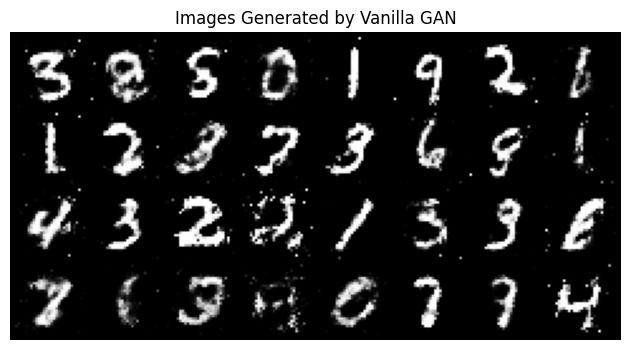

In [12]:
# ============================================================
# CELL 12: Generate MNIST digits using Vanilla GAN
# ============================================================

vanilla_G.eval()

with torch.no_grad():

    # Generate 32 random latent vectors.
    noise = torch.randn(
        32,
        LATENT_DIM,
        device=device
    )

    generated_images = vanilla_G(noise)

    # Convert:
    #
    # [32, 784]
    #
    # to
    #
    # [32, 1, 28, 28]

    generated_images = generated_images.view(
        -1, 1, 28, 28
    )

    # Convert from [-1,1] to [0,1].
    generated_images = (
        generated_images + 1
    ) / 2


grid = make_grid(
    generated_images.cpu(),
    nrow=8
)

plt.figure(figsize=(8, 4))

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title("Images Generated by Vanilla GAN")

plt.show()

In [13]:
# ============================================================
# CELL 13: Conditional GAN Generator
# ============================================================

NUM_CLASSES = 10

LABEL_EMBEDDING_DIM = 10


class ConditionalGenerator(nn.Module):

    def __init__(
        self,
        latent_dim=100,
        num_classes=10,
        embedding_dim=10
    ):

        super().__init__()


        # Convert labels such as:
        #
        # 0, 1, 2, ..., 9
        #
        # into learnable vectors.
        #
        # Example:
        #
        # digit 7
        #
        #       ↓
        #
        # [0.32, -0.17, ..., 0.91]

        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )


        # Generator input consists of:
        #
        # noise + label embedding
        #
        # 100 + 10 = 110 dimensions

        input_dim = latent_dim + embedding_dim


        self.model = nn.Sequential(

            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 28 * 28),

            nn.Tanh()
        )


    def forward(self, noise, labels):

        # Convert labels into embeddings.
        label_vectors = self.label_embedding(labels)

        # Concatenate:
        #
        # random noise z
        #
        # +
        #
        # information about digit y

        x = torch.cat(
            [noise, label_vectors],
            dim=1
        )

        image = self.model(x)

        return image

In [14]:
# ============================================================
# CELL 14: Conditional GAN Discriminator
# ============================================================

class ConditionalDiscriminator(nn.Module):

    def __init__(
        self,
        num_classes=10,
        embedding_dim=10
    ):

        super().__init__()


        # The discriminator also needs to know
        # which class the image is supposed to represent.

        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )


        # Image = 784 values
        # Label embedding = 10 values
        #
        # Total input = 794

        input_dim = 28 * 28 + embedding_dim


        self.model = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1)
        )


    def forward(self, image, labels):

        # Obtain label representation.
        label_vectors = self.label_embedding(labels)

        # Concatenate image and label.
        x = torch.cat(
            [image, label_vectors],
            dim=1
        )

        prediction = self.model(x)

        return prediction

In [15]:
# ============================================================
# CELL 15: Initialize Conditional GAN
# ============================================================

cgan_G = ConditionalGenerator(
    latent_dim=LATENT_DIM,
    num_classes=NUM_CLASSES,
    embedding_dim=LABEL_EMBEDDING_DIM
).to(device)


cgan_D = ConditionalDiscriminator(
    num_classes=NUM_CLASSES,
    embedding_dim=LABEL_EMBEDDING_DIM
).to(device)


criterion = nn.BCEWithLogitsLoss()


optimizer_cG = optim.Adam(
    cgan_G.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)


optimizer_cD = optim.Adam(
    cgan_D.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

In [16]:
# ============================================================
# CELL 16: Train Conditional GAN
# ============================================================

cgan_G.train()
cgan_D.train()


for epoch in range(NUM_EPOCHS):

    running_d_loss = 0
    running_g_loss = 0


    for real_images, real_labels in train_loader:

        batch_size = real_images.size(0)

        real_images = real_images.to(device)

        real_labels = real_labels.to(device)


        # Flatten images for MLP.
        real_images = real_images.view(
            batch_size,
            -1
        )


        # ====================================================
        # STEP 1: TRAIN CONDITIONAL DISCRIMINATOR
        # ====================================================

        optimizer_cD.zero_grad()


        # Real image + correct label
        real_output = cgan_D(
            real_images,
            real_labels
        )


        real_targets = torch.ones(
            batch_size,
            1,
            device=device
        )


        loss_real = criterion(
            real_output,
            real_targets
        )


        # ----------------------------------------------------
        # Generate fake images
        # ----------------------------------------------------

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )


        # Choose random labels for the generated images.
        fake_labels = torch.randint(
            0,
            NUM_CLASSES,
            (batch_size,),
            device=device
        )


        fake_images = cgan_G(
            noise,
            fake_labels
        )


        # ----------------------------------------------------
        # Discriminator sees:
        #
        # generated image + generated image's requested label
        # ----------------------------------------------------

        fake_output = cgan_D(
            fake_images.detach(),
            fake_labels
        )


        fake_targets = torch.zeros(
            batch_size,
            1,
            device=device
        )


        loss_fake = criterion(
            fake_output,
            fake_targets
        )


        d_loss = loss_real + loss_fake

        d_loss.backward()

        optimizer_cD.step()


        # ====================================================
        # STEP 2: TRAIN CONDITIONAL GENERATOR
        # ====================================================

        optimizer_cG.zero_grad()


        fake_output = cgan_D(
            fake_images,
            fake_labels
        )


        # Generator wants generated examples
        # to be classified as real.
        generator_targets = torch.ones(
            batch_size,
            1,
            device=device
        )


        g_loss = criterion(
            fake_output,
            generator_targets
        )


        g_loss.backward()

        optimizer_cG.step()


        running_d_loss += d_loss.item()
        running_g_loss += g_loss.item()


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"D Loss: {running_d_loss/len(train_loader):.4f} "
        f"G Loss: {running_g_loss/len(train_loader):.4f}"
    )

Epoch [1/25] D Loss: 1.0870 G Loss: 1.2174
Epoch [2/25] D Loss: 0.7665 G Loss: 2.5518
Epoch [3/25] D Loss: 0.7722 G Loss: 2.2545
Epoch [4/25] D Loss: 0.8226 G Loss: 2.0414
Epoch [5/25] D Loss: 0.7930 G Loss: 2.1068
Epoch [6/25] D Loss: 0.7715 G Loss: 2.2769
Epoch [7/25] D Loss: 0.8740 G Loss: 1.9021
Epoch [8/25] D Loss: 0.8314 G Loss: 1.9395
Epoch [9/25] D Loss: 0.8704 G Loss: 1.8531
Epoch [10/25] D Loss: 0.8044 G Loss: 2.0085
Epoch [11/25] D Loss: 0.8375 G Loss: 1.9605
Epoch [12/25] D Loss: 0.8855 G Loss: 1.7712
Epoch [13/25] D Loss: 0.9187 G Loss: 1.6853
Epoch [14/25] D Loss: 0.9395 G Loss: 1.6547
Epoch [15/25] D Loss: 1.0366 G Loss: 1.4256
Epoch [16/25] D Loss: 1.0839 G Loss: 1.3110
Epoch [17/25] D Loss: 1.0976 G Loss: 1.2402
Epoch [18/25] D Loss: 1.1276 G Loss: 1.2094
Epoch [19/25] D Loss: 1.1434 G Loss: 1.1960
Epoch [20/25] D Loss: 1.1806 G Loss: 1.1050
Epoch [21/25] D Loss: 1.1616 G Loss: 1.1338
Epoch [22/25] D Loss: 1.1966 G Loss: 1.0842
Epoch [23/25] D Loss: 1.1964 G Loss: 1.08

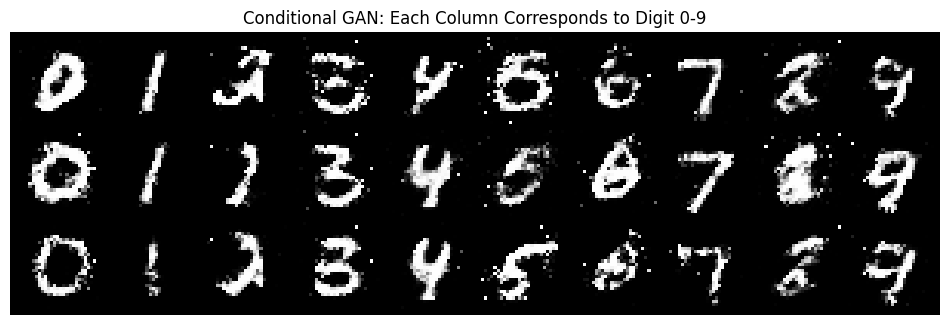

In [17]:
# ============================================================
# CELL 17: Generate specific digits
# ============================================================

cgan_G.eval()


# We explicitly ask the generator for:
#
# 0 1 2 3 4 5 6 7 8 9
#
# repeated three times.

requested_labels = torch.tensor(
    list(range(10)) * 3,
    device=device
)


with torch.no_grad():

    noise = torch.randn(
        len(requested_labels),
        LATENT_DIM,
        device=device
    )


    generated_images = cgan_G(
        noise,
        requested_labels
    )


    generated_images = generated_images.view(
        -1,
        1,
        28,
        28
    )


    generated_images = (
        generated_images + 1
    ) / 2


grid = make_grid(
    generated_images.cpu(),
    nrow=10
)


plt.figure(figsize=(12, 4))

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title(
    "Conditional GAN: "
    "Each Column Corresponds to Digit 0-9"
)

plt.show()

In [18]:
# ============================================================
# CELL 18: DCGAN Generator
# ============================================================

class DCGenerator(nn.Module):

    def __init__(self, latent_dim=100):

        super().__init__()


        # First convert the random vector into a small
        # spatial feature map:
        #
        # 100
        #
        # ↓
        #
        # 128 x 7 x 7

        self.fc = nn.Linear(
            latent_dim,
            128 * 7 * 7
        )


        self.conv_blocks = nn.Sequential(

            # ------------------------------------------------
            # Input:
            # 128 x 7 x 7
            #
            # Output:
            # 64 x 14 x 14
            # ------------------------------------------------

            nn.ConvTranspose2d(
                in_channels=128,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(True),


            # ------------------------------------------------
            # Input:
            # 64 x 14 x 14
            #
            # Output:
            # 1 x 28 x 28
            # ------------------------------------------------

            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            # Pixel values between -1 and +1.
            nn.Tanh()
        )


    def forward(self, z):

        # [B, 100]
        x = self.fc(z)


        # Reshape into an image-like tensor.
        #
        # [B, 128*7*7]
        #
        # ->
        #
        # [B, 128, 7, 7]

        x = x.view(
            -1,
            128,
            7,
            7
        )


        # Upsample through transposed convolutions.
        image = self.conv_blocks(x)

        return image

In [19]:
# ============================================================
# CELL 19: DCGAN Discriminator
# ============================================================

class DCDiscriminator(nn.Module):

    def __init__(self):

        super().__init__()


        self.conv_blocks = nn.Sequential(

            # ------------------------------------------------
            # Input:
            # 1 x 28 x 28
            #
            # Output:
            # 64 x 14 x 14
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=1,
                out_channels=64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            # ------------------------------------------------
            # Input:
            # 64 x 14 x 14
            #
            # Output:
            # 128 x 7 x 7
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            )
        )


        # Convert final feature map into one real/fake logit.
        self.fc = nn.Linear(
            128 * 7 * 7,
            1
        )


    def forward(self, image):

        x = self.conv_blocks(image)

        x = x.view(
            x.size(0),
            -1
        )

        output = self.fc(x)

        return output

In [20]:
# ============================================================
# CELL 20: Initialize DCGAN
# ============================================================

dcgan_G = DCGenerator(
    LATENT_DIM
).to(device)


dcgan_D = DCDiscriminator().to(device)


criterion = nn.BCEWithLogitsLoss()


optimizer_dcG = optim.Adam(
    dcgan_G.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)


optimizer_dcD = optim.Adam(
    dcgan_D.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

In [21]:
# ============================================================
# CELL 21: Train DCGAN
# ============================================================

dcgan_G.train()
dcgan_D.train()


for epoch in range(NUM_EPOCHS):

    running_d_loss = 0
    running_g_loss = 0


    for real_images, _ in train_loader:

        batch_size = real_images.size(0)

        # IMPORTANT:
        #
        # DO NOT flatten the images here.
        #
        # Conv2d expects:
        #
        # [batch, channels, height, width]

        real_images = real_images.to(device)


        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        optimizer_dcD.zero_grad()


        # ----- Real images -----

        real_output = dcgan_D(
            real_images
        )


        real_targets = torch.ones(
            batch_size,
            1,
            device=device
        )


        real_loss = criterion(
            real_output,
            real_targets
        )


        # ----- Fake images -----

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )


        fake_images = dcgan_G(noise)


        fake_output = dcgan_D(
            fake_images.detach()
        )


        fake_targets = torch.zeros(
            batch_size,
            1,
            device=device
        )


        fake_loss = criterion(
            fake_output,
            fake_targets
        )


        d_loss = real_loss + fake_loss

        d_loss.backward()

        optimizer_dcD.step()


        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        optimizer_dcG.zero_grad()


        fake_output = dcgan_D(
            fake_images
        )


        g_targets = torch.ones(
            batch_size,
            1,
            device=device
        )


        g_loss = criterion(
            fake_output,
            g_targets
        )


        g_loss.backward()

        optimizer_dcG.step()


        running_d_loss += d_loss.item()

        running_g_loss += g_loss.item()


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"D Loss: {running_d_loss/len(train_loader):.4f} "
        f"G Loss: {running_g_loss/len(train_loader):.4f}"
    )

Epoch [1/25] D Loss: 0.4090 G Loss: 2.2114
Epoch [2/25] D Loss: 0.3551 G Loss: 2.3781
Epoch [3/25] D Loss: 0.3538 G Loss: 2.4586
Epoch [4/25] D Loss: 0.3997 G Loss: 2.3680
Epoch [5/25] D Loss: 0.4432 G Loss: 2.3034
Epoch [6/25] D Loss: 0.4267 G Loss: 2.3330
Epoch [7/25] D Loss: 0.4044 G Loss: 2.4344
Epoch [8/25] D Loss: 0.3943 G Loss: 2.4970
Epoch [9/25] D Loss: 0.4144 G Loss: 2.5294
Epoch [10/25] D Loss: 0.3636 G Loss: 2.6449
Epoch [11/25] D Loss: 0.3490 G Loss: 2.7401
Epoch [12/25] D Loss: 0.3781 G Loss: 2.7649
Epoch [13/25] D Loss: 0.3319 G Loss: 2.8035
Epoch [14/25] D Loss: 0.3244 G Loss: 2.9325
Epoch [15/25] D Loss: 0.3134 G Loss: 2.9751
Epoch [16/25] D Loss: 0.3312 G Loss: 3.0306
Epoch [17/25] D Loss: 0.3063 G Loss: 3.0408
Epoch [18/25] D Loss: 0.3304 G Loss: 3.0351
Epoch [19/25] D Loss: 0.3041 G Loss: 3.1379
Epoch [20/25] D Loss: 0.3205 G Loss: 3.1534
Epoch [21/25] D Loss: 0.2776 G Loss: 3.2295
Epoch [22/25] D Loss: 0.2932 G Loss: 3.2624
Epoch [23/25] D Loss: 0.3439 G Loss: 3.17

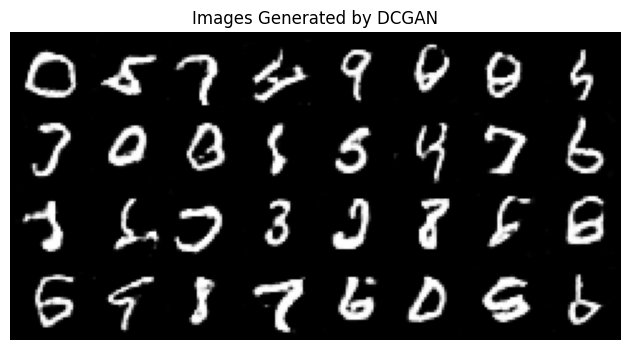

In [22]:
# ============================================================
# CELL 22: Visualize DCGAN generated images
# ============================================================

dcgan_G.eval()


with torch.no_grad():

    noise = torch.randn(
        32,
        LATENT_DIM,
        device=device
    )


    generated_images = dcgan_G(noise)


    # [-1,1] -> [0,1]
    generated_images = (
        generated_images + 1
    ) / 2


grid = make_grid(
    generated_images.cpu(),
    nrow=8
)


plt.figure(figsize=(8, 4))

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title("Images Generated by DCGAN")

plt.show()

In [23]:
# ============================================================
# CELL 23: Conditional DCGAN Generator
# ============================================================

class ConditionalDCGenerator(nn.Module):

    def __init__(
        self,
        latent_dim=100,
        num_classes=10,
        embedding_dim=20
    ):

        super().__init__()


        self.label_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )


        # Random noise + label information
        input_dim = latent_dim + embedding_dim


        self.fc = nn.Linear(
            input_dim,
            128 * 7 * 7
        )


        self.conv_blocks = nn.Sequential(

            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(True),


            nn.ConvTranspose2d(
                64,
                1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )


    def forward(self, noise, labels):

        # Get class embedding.
        label_vector = self.label_embedding(
            labels
        )


        # Combine:
        #
        # noise + desired digit information

        x = torch.cat(
            [noise, label_vector],
            dim=1
        )


        x = self.fc(x)


        x = x.view(
            -1,
            128,
            7,
            7
        )


        image = self.conv_blocks(x)

        return image

In [24]:
# ============================================================
# CELL 24: Conditional DCGAN Discriminator
# ============================================================

class ConditionalDCDiscriminator(nn.Module):

    def __init__(
        self,
        num_classes=10
    ):

        super().__init__()


        # Convert each class label into an entire 28x28 map.
        #
        # Example:
        #
        # label = 7
        #
        #    ↓
        #
        # learnable 28 x 28 representation

        self.label_embedding = nn.Embedding(
            num_classes,
            28 * 28
        )


        # We concatenate:
        #
        # Channel 1 -> image
        # Channel 2 -> label map
        #
        # Therefore discriminator input has 2 channels.

        self.conv_blocks = nn.Sequential(

            nn.Conv2d(
                2,
                64,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.LeakyReLU(
                0.2,
                inplace=True
            ),


            nn.Conv2d(
                64,
                128,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.LeakyReLU(
                0.2,
                inplace=True
            )
        )


        self.fc = nn.Linear(
            128 * 7 * 7,
            1
        )


    def forward(self, image, labels):

        # Convert labels:
        #
        # [B]
        #
        # ->
        #
        # [B, 784]
        #
        # ->
        #
        # [B, 1, 28, 28]

        label_map = self.label_embedding(
            labels
        )


        label_map = label_map.view(
            -1,
            1,
            28,
            28
        )


        # Concatenate image and label map
        # along the CHANNEL dimension.
        #
        # image:
        #       [B,1,28,28]
        #
        # label:
        #       [B,1,28,28]
        #
        # result:
        #       [B,2,28,28]

        x = torch.cat(
            [image, label_map],
            dim=1
        )


        x = self.conv_blocks(x)


        x = x.view(
            x.size(0),
            -1
        )


        output = self.fc(x)

        return output

In [25]:
# ============================================================
# CELL 25: Initialize Conditional DCGAN
# ============================================================

cdcgan_G = ConditionalDCGenerator(
    latent_dim=LATENT_DIM,
    num_classes=10,
    embedding_dim=20
).to(device)


cdcgan_D = ConditionalDCDiscriminator(
    num_classes=10
).to(device)


criterion = nn.BCEWithLogitsLoss()


optimizer_cdcG = optim.Adam(
    cdcgan_G.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)


optimizer_cdcD = optim.Adam(
    cdcgan_D.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

In [26]:
# ============================================================
# CELL 26: Train Conditional DCGAN
# ============================================================

cdcgan_G.train()
cdcgan_D.train()


for epoch in range(NUM_EPOCHS):

    running_d_loss = 0
    running_g_loss = 0


    for real_images, real_labels in train_loader:

        batch_size = real_images.size(0)

        real_images = real_images.to(device)

        real_labels = real_labels.to(device)


        # ====================================================
        # TRAIN DISCRIMINATOR
        # ====================================================

        optimizer_cdcD.zero_grad()


        # ----- Real examples -----

        real_output = cdcgan_D(
            real_images,
            real_labels
        )


        real_targets = torch.ones(
            batch_size,
            1,
            device=device
        )


        real_loss = criterion(
            real_output,
            real_targets
        )


        # ----- Fake examples -----

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )


        fake_labels = torch.randint(
            0,
            10,
            (batch_size,),
            device=device
        )


        fake_images = cdcgan_G(
            noise,
            fake_labels
        )


        fake_output = cdcgan_D(
            fake_images.detach(),
            fake_labels
        )


        fake_targets = torch.zeros(
            batch_size,
            1,
            device=device
        )


        fake_loss = criterion(
            fake_output,
            fake_targets
        )


        d_loss = (
            real_loss
            +
            fake_loss
        )


        d_loss.backward()

        optimizer_cdcD.step()


        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        optimizer_cdcG.zero_grad()


        fake_output = cdcgan_D(
            fake_images,
            fake_labels
        )


        generator_targets = torch.ones(
            batch_size,
            1,
            device=device
        )


        g_loss = criterion(
            fake_output,
            generator_targets
        )


        g_loss.backward()

        optimizer_cdcG.step()


        running_d_loss += d_loss.item()

        running_g_loss += g_loss.item()


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"D Loss: {running_d_loss/len(train_loader):.4f} "
        f"G Loss: {running_g_loss/len(train_loader):.4f}"
    )

Epoch [1/25] D Loss: 0.7552 G Loss: 1.5576
Epoch [2/25] D Loss: 0.7241 G Loss: 1.4949
Epoch [3/25] D Loss: 0.6705 G Loss: 1.6747
Epoch [4/25] D Loss: 0.7945 G Loss: 1.5258
Epoch [5/25] D Loss: 0.8507 G Loss: 1.4339
Epoch [6/25] D Loss: 0.9080 G Loss: 1.3834
Epoch [7/25] D Loss: 0.9232 G Loss: 1.3417
Epoch [8/25] D Loss: 0.9358 G Loss: 1.3523
Epoch [9/25] D Loss: 0.9271 G Loss: 1.3550
Epoch [10/25] D Loss: 0.9235 G Loss: 1.3671
Epoch [11/25] D Loss: 0.9166 G Loss: 1.3762
Epoch [12/25] D Loss: 0.9145 G Loss: 1.4046
Epoch [13/25] D Loss: 0.9202 G Loss: 1.3907
Epoch [14/25] D Loss: 0.9015 G Loss: 1.4124
Epoch [15/25] D Loss: 0.8903 G Loss: 1.4245
Epoch [16/25] D Loss: 0.8986 G Loss: 1.4429
Epoch [17/25] D Loss: 0.9149 G Loss: 1.4229
Epoch [18/25] D Loss: 0.8991 G Loss: 1.4445
Epoch [19/25] D Loss: 0.8846 G Loss: 1.4668
Epoch [20/25] D Loss: 0.8855 G Loss: 1.4912
Epoch [21/25] D Loss: 0.8918 G Loss: 1.4716
Epoch [22/25] D Loss: 0.8775 G Loss: 1.4983
Epoch [23/25] D Loss: 0.8961 G Loss: 1.48

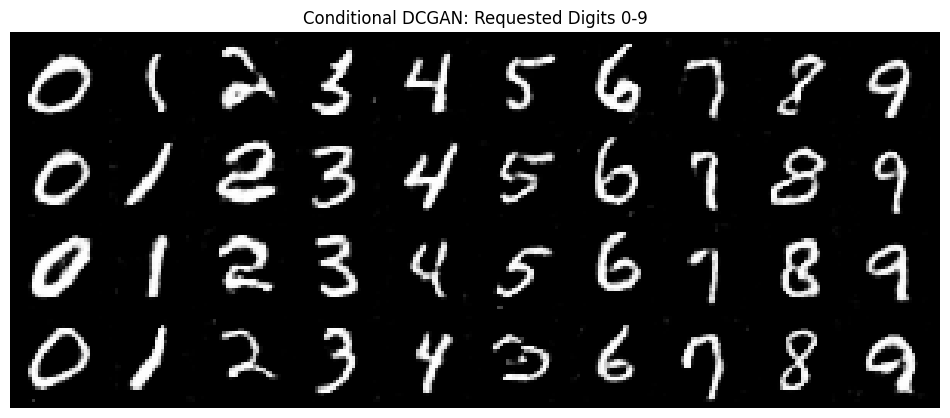

In [27]:
# ============================================================
# CELL 27: Generate requested digits with Conditional DCGAN
# ============================================================

cdcgan_G.eval()


# Ask for 0-9 four times.
labels = torch.tensor(
    list(range(10)) * 4,
    device=device
)


with torch.no_grad():

    noise = torch.randn(
        len(labels),
        LATENT_DIM,
        device=device
    )


    generated_images = cdcgan_G(
        noise,
        labels
    )


    generated_images = (
        generated_images + 1
    ) / 2


grid = make_grid(
    generated_images.cpu(),
    nrow=10
)


plt.figure(figsize=(12, 5))

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title(
    "Conditional DCGAN: Requested Digits 0-9"
)

plt.show()

In [28]:
# ============================================================
# CELL 30: Import FID
# ============================================================

from torchmetrics.image.fid import FrechetInceptionDistance

In [29]:
# ============================================================
# CELL 31: Convert MNIST images for FID
# ============================================================

def prepare_images_for_fid(images):

    """
    Prepare MNIST images for FID calculation.

    INPUT
    -----
    images:
        Tensor with shape

        [batch_size, 1, 28, 28]

        and pixel values in [-1, 1].

    OUTPUT
    ------
    Tensor with shape

        [batch_size, 3, 28, 28]

        and pixel values in [0, 1].
    """


    # --------------------------------------------------------
    # Step 1:
    # Convert pixel range from [-1,1] to [0,1].
    # --------------------------------------------------------

    images = (
        images + 1
    ) / 2


    # Avoid very small numerical values outside [0,1].
    images = images.clamp(
        0,
        1
    )


    # --------------------------------------------------------
    # Step 2:
    # MNIST has ONE channel.
    #
    # Inception expects THREE channels.
    #
    # Repeat:
    #
    # [B,1,H,W]
    #
    # ->
    #
    # [B,3,H,W]
    # --------------------------------------------------------

    images = images.repeat(
        1,
        3,
        1,
        1
    )


    return images

In [30]:
# ============================================================
# CELL 32: Compute FID for DCGAN
# ============================================================

# feature=2048 tells FID to use the standard
# 2048-dimensional Inception feature representation.
#
# normalize=True means input images should be
# floating-point tensors in [0,1].

fid = FrechetInceptionDistance(
    feature=2048,
    normalize=True
).to(device)


# Number of images used to estimate FID.
#
# For a quick classroom demo:
#     5,000
#
# For a more serious experiment:
#     10,000 or more

NUM_FID_IMAGES = 5000

num_processed = 0


dcgan_G.eval()


with torch.no_grad():

    for real_images, _ in train_loader:

        if num_processed >= NUM_FID_IMAGES:
            break


        real_images = real_images.to(device)

        batch_size = real_images.size(0)


        # ----------------------------------------------------
        # REAL images
        # ----------------------------------------------------

        real_fid_images = prepare_images_for_fid(
            real_images
        )


        # Tell FID these are REAL images.
        fid.update(
            real_fid_images,
            real=True
        )


        # ----------------------------------------------------
        # GENERATED images
        # ----------------------------------------------------

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )


        fake_images = dcgan_G(noise)


        fake_fid_images = prepare_images_for_fid(
            fake_images
        )


        # Tell FID these are GENERATED images.
        fid.update(
            fake_fid_images,
            real=False
        )


        num_processed += batch_size


# ------------------------------------------------------------
# Compute final FID
# ------------------------------------------------------------

fid_score = fid.compute()


print(
    "Number of images used:",
    num_processed
)

print(
    "FID Score:",
    fid_score.item()
)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 183MB/s]


Number of images used: 5120
FID Score: 21.7244873046875


In [31]:
# ============================================================
# CELL 33: Reusable FID function
#          for unconditional GANs
# ============================================================

def calculate_fid_unconditional(
    generator,
    dataloader,
    latent_dim=100,
    num_images=5000
):

    """
    Calculate FID between real MNIST images and images
    generated by an unconditional GAN.

    Examples:
        Vanilla GAN
        DCGAN
    """


    # Create FID metric.
    fid_metric = FrechetInceptionDistance(
        feature=2048,
        normalize=True
    ).to(device)


    generator.eval()


    total_images = 0


    with torch.no_grad():

        for real_images, _ in dataloader:

            if total_images >= num_images:
                break


            real_images = real_images.to(device)

            batch_size = real_images.size(0)


            # ------------------------------------------------
            # Add REAL images to FID
            # ------------------------------------------------

            real_fid = prepare_images_for_fid(
                real_images
            )


            fid_metric.update(
                real_fid,
                real=True
            )


            # ------------------------------------------------
            # Generate FAKE images
            # ------------------------------------------------

            noise = torch.randn(
                batch_size,
                latent_dim,
                device=device
            )


            fake_images = generator(noise)


            # Some generators may produce flattened images.
            #
            # Vanilla GAN:
            #       [B,784]
            #
            # DCGAN:
            #       [B,1,28,28]

            if fake_images.dim() == 2:

                fake_images = fake_images.view(
                    -1,
                    1,
                    28,
                    28
                )


            fake_fid = prepare_images_for_fid(
                fake_images
            )


            fid_metric.update(
                fake_fid,
                real=False
            )


            total_images += batch_size


    score = fid_metric.compute()


    return score.item()

In [32]:
# ============================================================
# CELL 34: Compare Vanilla GAN and DCGAN using FID
# ============================================================

vanilla_fid = calculate_fid_unconditional(
    vanilla_G,
    train_loader,
    latent_dim=LATENT_DIM,
    num_images=5000
)


dcgan_fid = calculate_fid_unconditional(
    dcgan_G,
    train_loader,
    latent_dim=LATENT_DIM,
    num_images=5000
)


print(
    f"Vanilla GAN FID : {vanilla_fid:.2f}"
)

print(
    f"DCGAN FID       : {dcgan_fid:.2f}"
)

Vanilla GAN FID : 80.88
DCGAN FID       : 20.88


In [33]:
# ============================================================
# CELL 35: FID function for Conditional GAN
# ============================================================

def calculate_fid_conditional(
    generator,
    dataloader,
    latent_dim=100,
    num_classes=10,
    num_images=5000
):

    """
    Calculate FID for a conditional generator.

    The generator must accept:

        generator(noise, labels)
    """


    fid_metric = FrechetInceptionDistance(
        feature=2048,
        normalize=True
    ).to(device)


    generator.eval()


    total_images = 0


    with torch.no_grad():

        for real_images, _ in dataloader:

            if total_images >= num_images:
                break


            real_images = real_images.to(device)

            batch_size = real_images.size(0)


            # =================================================
            # REAL IMAGES
            # =================================================

            real_fid = prepare_images_for_fid(
                real_images
            )


            fid_metric.update(
                real_fid,
                real=True
            )


            # =================================================
            # GENERATED IMAGES
            # =================================================

            noise = torch.randn(
                batch_size,
                latent_dim,
                device=device
            )


            # Random requested digit labels.
            labels = torch.randint(
                0,
                num_classes,
                (batch_size,),
                device=device
            )


            fake_images = generator(
                noise,
                labels
            )


            # MLP Conditional GAN returns [B,784].
            #
            # Conditional DCGAN already returns
            # [B,1,28,28].

            if fake_images.dim() == 2:

                fake_images = fake_images.view(
                    -1,
                    1,
                    28,
                    28
                )


            fake_fid = prepare_images_for_fid(
                fake_images
            )


            fid_metric.update(
                fake_fid,
                real=False
            )


            total_images += batch_size


    score = fid_metric.compute()


    return score.item()

In [34]:
# ============================================================
# CELL 36: Compare all GAN models
# ============================================================

print("Calculating Vanilla GAN FID...")

fid_vanilla = calculate_fid_unconditional(
    vanilla_G,
    train_loader,
    num_images=5000
)


print("Calculating Conditional GAN FID...")

fid_cgan = calculate_fid_conditional(
    cgan_G,
    train_loader,
    num_images=5000
)


print("Calculating DCGAN FID...")

fid_dcgan = calculate_fid_unconditional(
    dcgan_G,
    train_loader,
    num_images=5000
)


print("Calculating Conditional DCGAN FID...")

fid_cdcgan = calculate_fid_conditional(
    cdcgan_G,
    train_loader,
    num_images=5000
)


print("\n==============================")
print("       FID COMPARISON")
print("==============================")

print(
    f"Vanilla GAN        : {fid_vanilla:.2f}"
)

print(
    f"Conditional GAN    : {fid_cgan:.2f}"
)

print(
    f"DCGAN              : {fid_dcgan:.2f}"
)

print(
    f"Conditional DCGAN  : {fid_cdcgan:.2f}"
)

print("==============================")
print("Lower FID is better.")

Calculating Vanilla GAN FID...
Calculating Conditional GAN FID...
Calculating DCGAN FID...
Calculating Conditional DCGAN FID...

       FID COMPARISON
Vanilla GAN        : 81.56
Conditional GAN    : 111.89
DCGAN              : 20.35
Conditional DCGAN  : 14.32
Lower FID is better.


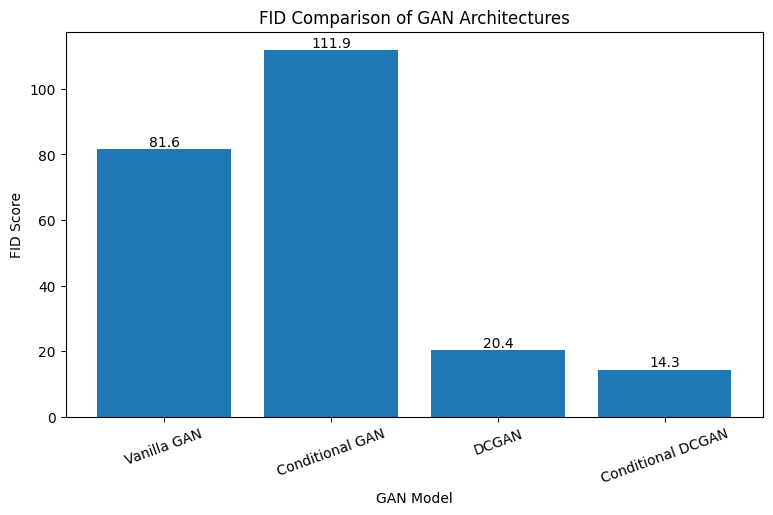

In [35]:
# ============================================================
# CELL 37: Plot FID scores
# ============================================================

model_names = [
    "Vanilla GAN",
    "Conditional GAN",
    "DCGAN",
    "Conditional DCGAN"
]


fid_scores = [
    fid_vanilla,
    fid_cgan,
    fid_dcgan,
    fid_cdcgan
]


plt.figure(figsize=(9, 5))


bars = plt.bar(
    model_names,
    fid_scores
)


plt.ylabel("FID Score")

plt.xlabel("GAN Model")

plt.title(
    "FID Comparison of GAN Architectures"
)


# Display numerical value above every bar.
for bar, score in zip(
    bars,
    fid_scores
):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{score:.1f}",
        ha="center",
        va="bottom"
    )


plt.xticks(rotation=20)

plt.show()

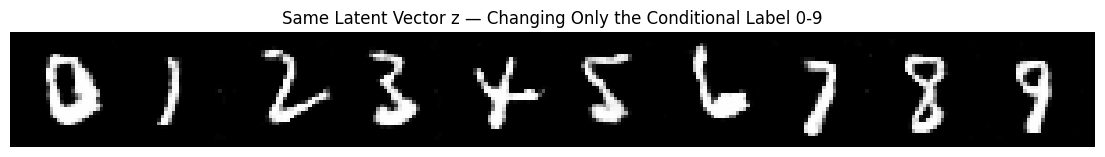

In [36]:
# ============================================================
# CELL 38:
# Same random noise + different labels
# ============================================================

cdcgan_G.eval()


# Generate ONE random latent vector.
single_noise = torch.randn(
    1,
    LATENT_DIM,
    device=device
)


# Repeat THE SAME latent vector 10 times.
#
# Therefore every generated image receives exactly
# the same z.

same_noise = single_noise.repeat(
    10,
    1
)


# But change the requested class.
labels = torch.arange(
    0,
    10,
    device=device
)


with torch.no_grad():

    images = cdcgan_G(
        same_noise,
        labels
    )


    images = (
        images + 1
    ) / 2


grid = make_grid(
    images.cpu(),
    nrow=10
)


plt.figure(figsize=(14, 2))

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title(
    "Same Latent Vector z — Changing Only the Conditional Label 0-9"
)

plt.show()

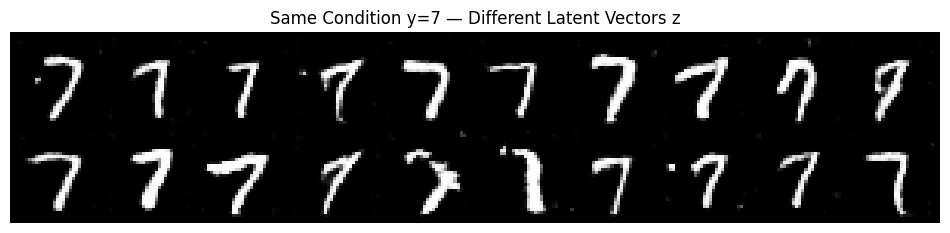

In [37]:
# ============================================================
# CELL 39:
# Same class label + different random vectors
# ============================================================

NUM_SAMPLES = 20


# Generate different random latent vectors.
noise = torch.randn(
    NUM_SAMPLES,
    LATENT_DIM,
    device=device
)


# Ask for digit 7 every time.
labels = torch.full(
    (NUM_SAMPLES,),
    7,
    dtype=torch.long,
    device=device
)


with torch.no_grad():

    images = cdcgan_G(
        noise,
        labels
    )


    images = (
        images + 1
    ) / 2


grid = make_grid(
    images.cpu(),
    nrow=10
)


plt.figure(figsize=(12, 4))

plt.imshow(
    grid.permute(1, 2, 0)
)

plt.axis("off")

plt.title(
    "Same Condition y=7 — Different Latent Vectors z"
)

plt.show()